In [ ]:
import pandas as pd
df=pd.read_csv("/content/used_cars.csv")
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


In [ ]:
df.shape

(4009, 12)

In [6]:
from sklearn.linear_model import LinearRegression
import pandas as pd

df=pd.read_csv("/content/used_cars.csv")

df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False)
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df = df.dropna(subset=['milage', 'price'])

X=df[["milage"]]
Y=df["price"]
model=LinearRegression()
model.fit(X,Y)
print(model.predict([[10]]))

[74308.6077693]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [9]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

df = pd.read_csv("/content/used_cars.csv")


df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')


df['model_year'] = pd.to_numeric(df['model_year'], errors='coerce')


df = df.dropna(subset=['price', 'model_year'])

X = df[["price"]]
y = df["model_year"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print(model.predict(pd.DataFrame([[555]], columns=['price'])))

[2022]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Prediction for new car (Accident history):
Result: No Accident Reported


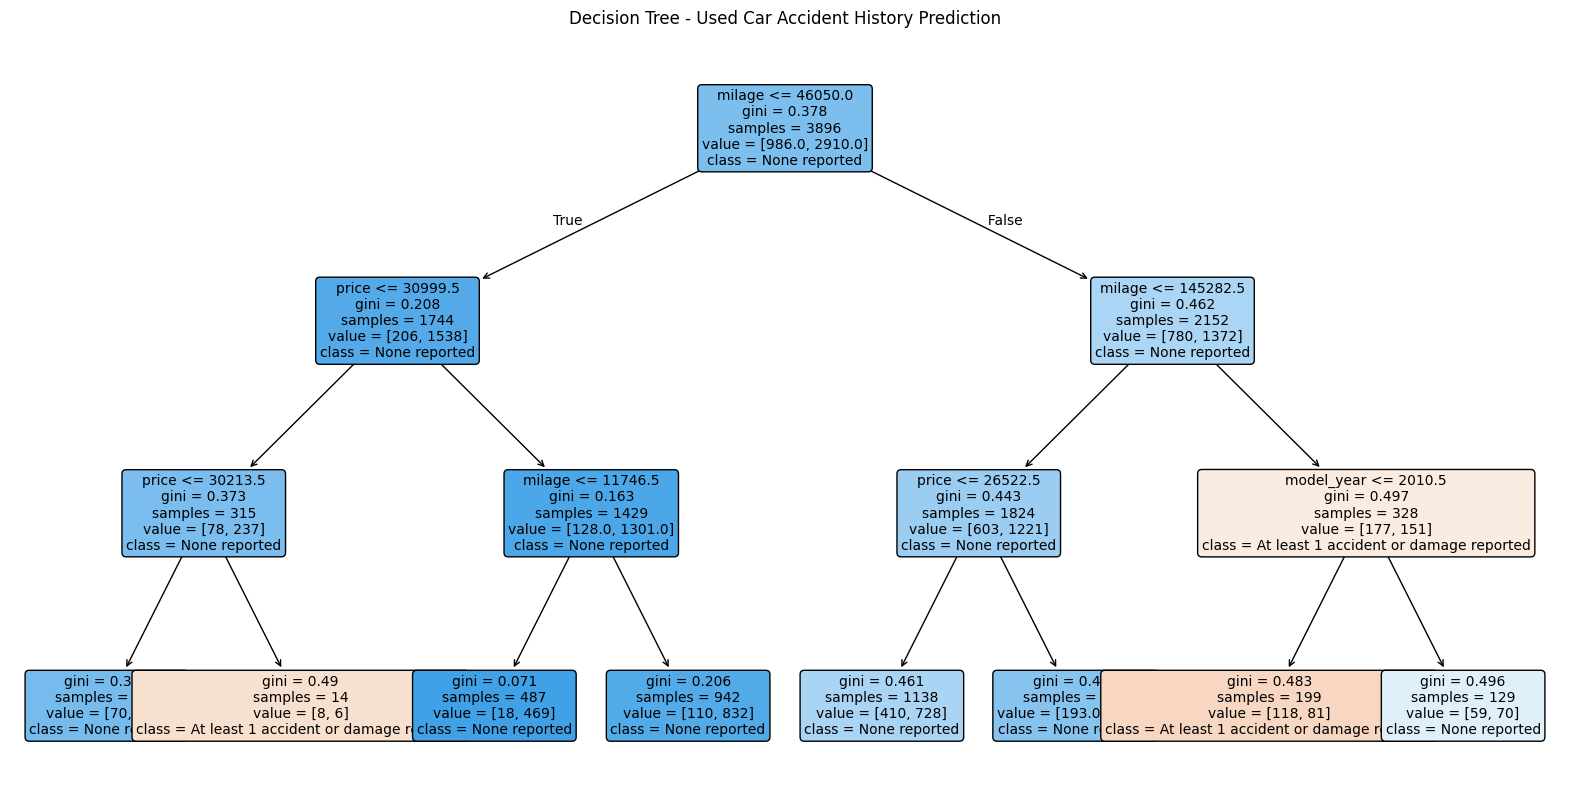

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


df = pd.read_csv("/content/used_cars.csv")


df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False)
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df = df.dropna(subset=['milage', 'price', 'model_year', 'accident'])


X = df[["model_year", "milage", "price"]]
y = df["accident"]


model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
model.fit(X, y)


new_car_data = pd.DataFrame([[2020, 45000, 25000]], columns=X.columns)

prediction = model.predict(new_car_data)
print("\nPrediction for new car (Accident history):")
if prediction[0] == "None reported":
    print("Result: No Accident Reported")
else:
    print("Result: Accident or Damage Reported")


plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree - Used Car Accident History Prediction")
plt.show()

Dataset Preview (first 5 rows):


,model_year,milage,price,fuel_type
0,2013,51000,10300,E85 Flex Fuel
1,2021,34742,38005,Gasoline
2,2022,22372,54598,Gasoline
3,2015,88900,15500,Hybrid
4,2021,9835,34999,Gasoline



Predicted Fuel Type for new car: Gasoline

Probabilities per fuel type:
Probability of Diesel: 3.17%
Probability of E85 Flex Fuel: 0.85%
Probability of Gasoline: 82.37%
Probability of Hybrid: 11.57%
Probability of Plug-In Hybrid: 1.68%
Probability of not supported: 0.00%
Probability of –: 0.36%


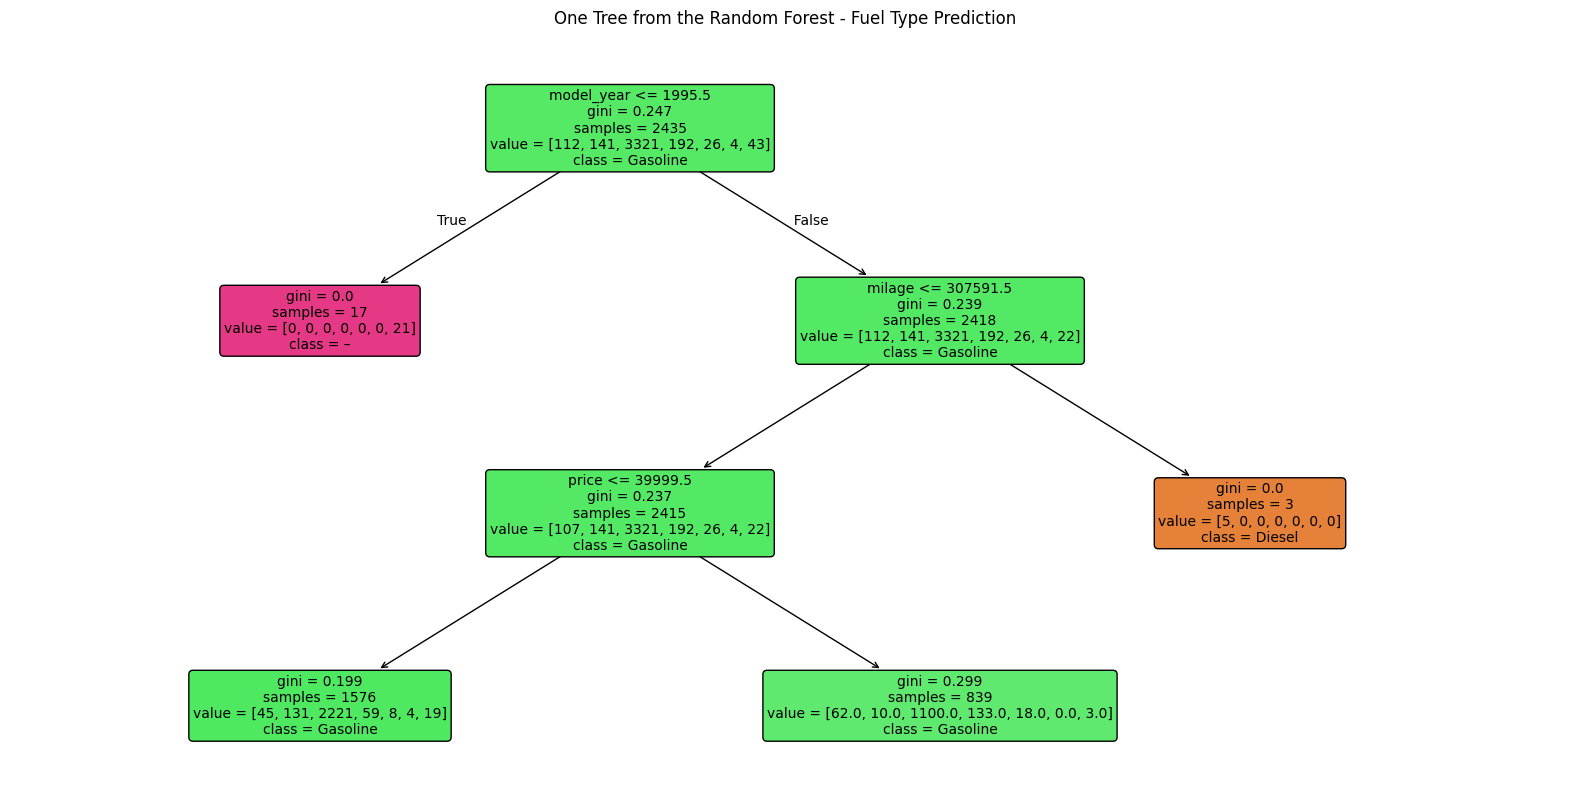

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

df = pd.read_csv("/content/used_cars.csv")


df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False)
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')


df = df.dropna(subset=['model_year', 'milage', 'price', 'fuel_type'])


X = df[["model_year", "milage", "price"]]
y = df["fuel_type"]

model = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)
model.fit(X, y)

print("Dataset Preview (first 5 rows):")
display(df[['model_year', 'milage', 'price', 'fuel_type']].head())

new_car_data = pd.DataFrame([[2022, 15000, 50000]], columns=X.columns)
prediction = model.predict(new_car_data)
probabilities = model.predict_proba(new_car_data)

print(f"\nPredicted Fuel Type for new car: {prediction[0]}")
print("\nProbabilities per fuel type:")
for cls, prob in zip(model.classes_, probabilities[0]):
    print(f"Probability of {cls}: {prob:.2%}")


plt.figure(figsize=(20, 10))
plot_tree(
    model.estimators_[0],
    filled=True,
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in model.classes_],
    rounded=True,
    fontsize=10
)
plt.title("One Tree from the Random Forest - Fuel Type Prediction")
plt.show()

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


df = pd.read_csv("/content/used_cars.csv")


df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False)
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')


df = df.dropna(subset=['model_year', 'milage', 'price', 'fuel_type'])


X = df[["model_year", "milage", "price"]]
y = df["fuel_type"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_scaled, y)

new_car_unscaled = pd.DataFrame([[2022, 15000, 50000]], columns=X.columns)
new_car_scaled = scaler.transform(new_car_unscaled)

prediction_svm = model_svm.predict(new_car_scaled)

print("\nPrediction for new car fuel type using SVM:")
print(f"Result: {prediction_svm[0]}")


Prediction for new car fuel type using SVM:
Result: Gasoline


In [ ]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB


df = pd.read_csv("/content/used_cars.csv")


df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False)
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')


df = df.dropna(subset=['milage', 'price', 'model_year', 'accident'])


X = df[["model_year", "milage", "price"]]
y = df["accident"]


model_nb = GaussianNB()
model_nb.fit(X, y)


new_car_data = pd.DataFrame([[2020, 45000, 25000]], columns=X.columns)

prediction_nb = model_nb.predict(new_car_data)
probabilities = model_nb.predict_proba(new_car_data)

print("\nPrediction for new car (Accident history) using Naive Bayes:")
if prediction_nb[0] == "None reported":
    print("Result: No Accident Reported")
else:
    print("Result: Accident or Damage Reported")


for cls, prob in zip(model_nb.classes_, probabilities[0]):
    print(f"Probability of {cls}: {prob:.2%}")


Prediction for new car (Accident history) using Naive Bayes:
Result: No Accident Reported
Probability of At least 1 accident or damage reported: 10.78%
Probability of None reported: 89.22%


In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier


df = pd.read_csv("/content/used_cars.csv")

df['milage'] = df['milage'].astype(str).str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False)
df['milage'] = pd.to_numeric(df['milage'], errors='coerce')

df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')


df = df.dropna(subset=['milage', 'price', 'model_year', 'fuel_type'])


X = df[["model_year", "milage", "price"]]
y = df["fuel_type"]

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X, y)


new_car = pd.DataFrame([[2022, 15000, 50000]], columns=X.columns)

prediction = model_knn.predict(new_car)
probabilities = model_knn.predict_proba(new_car)

print("Prediction for fuel type using KNN:")
print(f"Result: {prediction[0]}")

print("\nProbabilities per fuel type:")
for cls, prob in zip(model_knn.classes_, probabilities[0]):
    print(f"Probability of {cls}: {prob:.2%}")

Prediction for fuel type using KNN:
Result: Gasoline

Probabilities per fuel type:
Probability of Diesel: 0.00%
Probability of E85 Flex Fuel: 0.00%
Probability of Gasoline: 80.00%
Probability of Hybrid: 20.00%
Probability of Plug-In Hybrid: 0.00%
Probability of not supported: 0.00%
Probability of –: 0.00%
